# Fraud Detection Algorithm

In [1]:
# Install packages
import sys

print("Notebook Python executable:")
print(sys.executable)

!{sys.executable} -m pip install pandas numpy scikit-learn imbalanced-learn xgboost joblib matplotlib kagglehub

Notebook Python executable:
c:\Python311\python.exe



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Imports
import os
import sys
import json
import joblib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

print("All imports successful")
print("Python executable:", sys.executable)

All imports successful
Python executable: c:\Python311\python.exe


In [3]:
# Download Dataset
import kagglehub

dataset_path = kagglehub.dataset_download("rohitrox/healthcare-provider-fraud-detection-analysis")
print("Dataset path:", dataset_path)

DATASET_DIR = Path(dataset_path)

Dataset path: C:\Users\Kunal Chawla\.cache\kagglehub\datasets\rohitrox\healthcare-provider-fraud-detection-analysis\versions\1


In [4]:
# Load Files
train_path = list(DATASET_DIR.glob("Train-*.csv"))[0]
beneficiary_path = list(DATASET_DIR.glob("Train_Beneficiarydata-*.csv"))[0]
inpatient_path = list(DATASET_DIR.glob("Train_Inpatientdata-*.csv"))[0]
outpatient_path = list(DATASET_DIR.glob("Train_Outpatientdata-*.csv"))[0]

train = pd.read_csv(train_path)
beneficiary = pd.read_csv(beneficiary_path)
inpatient = pd.read_csv(inpatient_path)
outpatient = pd.read_csv(outpatient_path)

print("Train:", train.shape)
print("Beneficiary:", beneficiary.shape)
print("Inpatient:", inpatient.shape)
print("Outpatient:", outpatient.shape)

Train: (5410, 2)
Beneficiary: (138556, 25)
Inpatient: (40474, 30)
Outpatient: (517737, 27)


In [5]:
# Merge Datasets 
common_cols = [
    "BeneID", "ClaimID", "ClaimStartDt", "ClaimEndDt", "Provider",
    "InscClaimAmtReimbursed", "AttendingPhysician", "OperatingPhysician",
    "OtherPhysician", "ClmDiagnosisCode_1", "ClmDiagnosisCode_2",
    "ClmDiagnosisCode_3", "ClmDiagnosisCode_4", "ClmDiagnosisCode_5",
    "ClmDiagnosisCode_6", "ClmDiagnosisCode_7", "ClmDiagnosisCode_8",
    "ClmDiagnosisCode_9", "ClmDiagnosisCode_10", "ClmProcedureCode_1",
    "ClmProcedureCode_2", "ClmProcedureCode_3", "ClmProcedureCode_4",
    "ClmProcedureCode_5", "ClmProcedureCode_6", "DeductibleAmtPaid",
    "ClmAdmitDiagnosisCode"
]

all_patients = pd.merge(outpatient, inpatient, how="outer", on=common_cols)
all_patients = pd.merge(all_patients, beneficiary, on="BeneID", how="left")
all_patients = pd.merge(all_patients, train, on="Provider", how="left")

print("Merged shape:", all_patients.shape)
all_patients.head()

Merged shape: (558211, 55)


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode,AdmissionDt,DischargeDt,DiagnosisGroupCode,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,PotentialFraud
0,BENE100000,CLM126832,2009-01-08,2009-01-08,PRV57172,50,PHY383401,NaN,NaN,79678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,1938-03-01,NaN,1,1,0,49,430,12,12,2,2,2,2,2,2,2,1,2,2,2,0,0,120,30,Yes
1,BENE100000,CLM351838,2009-05-10,2009-05-10,PRV57172,70,PHY370909,NaN,PHY363377,71656,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,1938-03-01,NaN,1,1,0,49,430,12,12,2,2,2,2,2,2,2,1,2,2,2,0,0,120,30,Yes
2,BENE100001,CLM229075,2009-03-05,2009-03-05,PRV55158,70,PHY383478,NaN,NaN,64881,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,64880,NaN,NaN,NaN,1939-08-01,NaN,1,1,0,33,420,12,12,1,2,2,2,2,2,2,1,1,2,1,0,0,2530,540,No
3,BENE100001,CLM258631,2009-03-21,2009-03-21,PRV54966,70,PHY347511,NaN,NaN,36401,V4569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,36401,NaN,NaN,NaN,1939-08-01,NaN,1,1,0,33,420,12,12,1,2,2,2,2,2,2,1,1,2,1,0,0,2530,540,Yes
4,BENE100001,CLM332544,2009-04-30,2009-05-02,PRV54890,90,PHY343317,PHY408367,PHY408367,2948,4019,2989,78054,2875,78830,71596,V1251,7993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,78009,NaN,NaN,NaN,1939-08-01,NaN,1,1,0,33,420,12,12,1,2,2,2,2,2,2,1,1,2,1,0,0,2530,540,No


In [6]:
# Preprocessing and Feature Engineering
df = all_patients.copy()

def physician_same(row):
    attending = row.get("AttendingPhysician")
    operating = row.get("OperatingPhysician")
    other = row.get("OtherPhysician")

    a = attending == operating
    b = operating == other

    if a and b:
        return 0
    elif a and not b:
        return 1
    elif not a and b:
        return 2
    else:
        return 3

def physician_count(row):
    cols = ["AttendingPhysician", "OperatingPhysician", "OtherPhysician"]
    return sum(pd.notna(row.get(col)) for col in cols)

df["phy_same"] = df.apply(physician_same, axis=1)
df["phy_count"] = df.apply(physician_count, axis=1)

date_cols = ["ClaimStartDt", "ClaimEndDt", "AdmissionDt", "DischargeDt", "DOB", "DOD"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df["claim_period_days"] = (df["ClaimEndDt"] - df["ClaimStartDt"]).dt.days
df["admission_period_days"] = (df["DischargeDt"] - df["AdmissionDt"]).dt.days
df["admission_period_days"] = df["admission_period_days"].fillna(0)

chronic_cols = [c for c in df.columns if c.startswith("ChronicCond")]
for col in chronic_cols:
    df[col] = df[col].replace({2: 0})

if "Gender" in df.columns:
    df["Gender"] = df["Gender"].replace({2: 0})

if "RenalDiseaseIndicator" in df.columns:
    df["RenalDiseaseIndicator"] = df["RenalDiseaseIndicator"].replace({"Y": 1}).fillna(0)

max_dod = df["DOD"].dropna().max()
if pd.isna(max_dod):
    max_dod = pd.Timestamp.today()

df["alife"] = df["DOD"].isna().astype(int)
df["DOD_filled"] = df["DOD"].fillna(max_dod)
df["age"] = ((df["DOD_filled"] - df["DOB"]).dt.days / 365.25).fillna(0).astype(int)

df["PotentialFraud"] = df["PotentialFraud"].replace({"Yes": 1, "No": 0})

df.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode,AdmissionDt,DischargeDt,DiagnosisGroupCode,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,PotentialFraud,phy_same,phy_count,claim_period_days,admission_period_days,alife,DOD_filled,age
0,BENE100000,CLM126832,2009-01-08,2009-01-08,PRV57172,50,PHY383401,NaN,NaN,79678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaT,NaT,NaN,1938-03-01,NaT,1,1,0,49,430,12,12,0,0,0,0,0,0,0,1,0,0,0,0,0,120,30,1,3,1,0,0.0,1,2009-12-01,71
1,BENE100000,CLM351838,2009-05-10,2009-05-10,PRV57172,70,PHY370909,NaN,PHY363377,71656,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaT,NaT,NaN,1938-03-01,NaT,1,1,0,49,430,12,12,0,0,0,0,0,0,0,1,0,0,0,0,0,120,30,1,3,2,0,0.0,1,2009-12-01,71
2,BENE100001,CLM229075,2009-03-05,2009-03-05,PRV55158,70,PHY383478,NaN,NaN,64881,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,64880,NaT,NaT,NaN,1939-08-01,NaT,1,1,0,33,420,12,12,1,0,0,0,0,0,0,1,1,0,1,0,0,2530,540,0,3,1,0,0.0,1,2009-12-01,70
3,BENE100001,CLM258631,2009-03-21,2009-03-21,PRV54966,70,PHY347511,NaN,NaN,36401,V4569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,36401,NaT,NaT,NaN,1939-08-01,NaT,1,1,0,33,420,12,12,1,0,0,0,0,0,0,1,1,0,1,0,0,2530,540,1,3,1,0,0.0,1,2009-12-01,70
4,BENE100001,CLM332544,2009-04-30,2009-05-02,PRV54890,90,PHY343317,PHY408367,PHY408367,2948,4019,2989,78054,2875,78830,71596,V1251,7993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,78009,NaT,NaT,NaN,1939-08-01,NaT,1,1,0,33,420,12,12,1,0,0,0,0,0,0,1,1,0,1,0,0,2530,540,0,2,3,2,0.0,1,2009-12-01,70


In [7]:
# Statistical features and provider level aggregation
money_cols = [
    "InscClaimAmtReimbursed",
    "DeductibleAmtPaid",
    "NoOfMonths_PartACov",
    "NoOfMonths_PartBCov",
    "IPAnnualReimbursementAmt",
    "IPAnnualDeductibleAmt",
    "OPAnnualReimbursementAmt",
    "OPAnnualDeductibleAmt",
]

def grouped_stats(dataframe, group_col, cols, prefix):
    grouped = dataframe.groupby(group_col)[cols].agg(["mean", "std"]).reset_index()
    grouped.columns = [group_col] + [f"{prefix}_{c}_{agg}" for c, agg in grouped.columns.tolist()[1:]]
    return grouped

provider_stats = grouped_stats(df, "Provider", money_cols, "provider")
bene_stats = grouped_stats(df, "BeneID", money_cols, "bene")
diag_stats = grouped_stats(df, "ClmDiagnosisCode_1", money_cols, "diag1")

df = df.merge(provider_stats, on="Provider", how="left")
df = df.merge(bene_stats, on="BeneID", how="left")
df = df.merge(diag_stats, on="ClmDiagnosisCode_1", how="left")

selected_base_cols = [
    "Provider",
    "PotentialFraud",
    "phy_same",
    "phy_count",
    "claim_period_days",
    "admission_period_days",
    "age",
    "alife",
]

feature_cols = selected_base_cols + [
    col for col in df.columns
    if col.startswith("provider_") or col.startswith("bene_") or col.startswith("diag1_")
]

provider_level = df[feature_cols].groupby(["Provider", "PotentialFraud"], as_index=False).mean()
provider_level = provider_level.fillna(0)

print("Provider-level shape:", provider_level.shape)
provider_level.head()

Provider-level shape: (5410, 56)


,Provider,PotentialFraud,phy_same,phy_count,claim_period_days,admission_period_days,age,alife,provider_InscClaimAmtReimbursed_mean,provider_InscClaimAmtReimbursed_std,provider_DeductibleAmtPaid_mean,provider_DeductibleAmtPaid_std,provider_NoOfMonths_PartACov_mean,provider_NoOfMonths_PartACov_std,provider_NoOfMonths_PartBCov_mean,provider_NoOfMonths_PartBCov_std,provider_IPAnnualReimbursementAmt_mean,provider_IPAnnualReimbursementAmt_std,provider_IPAnnualDeductibleAmt_mean,provider_IPAnnualDeductibleAmt_std,provider_OPAnnualReimbursementAmt_mean,provider_OPAnnualReimbursementAmt_std,provider_OPAnnualDeductibleAmt_mean,provider_OPAnnualDeductibleAmt_std,bene_InscClaimAmtReimbursed_mean,bene_InscClaimAmtReimbursed_std,bene_DeductibleAmtPaid_mean,bene_DeductibleAmtPaid_std,bene_NoOfMonths_PartACov_mean,bene_NoOfMonths_PartACov_std,bene_NoOfMonths_PartBCov_mean,bene_NoOfMonths_PartBCov_std,bene_IPAnnualReimbursementAmt_mean,bene_IPAnnualReimbursementAmt_std,bene_IPAnnualDeductibleAmt_mean,bene_IPAnnualDeductibleAmt_std,bene_OPAnnualReimbursementAmt_mean,bene_OPAnnualReimbursementAmt_std,bene_OPAnnualDeductibleAmt_mean,bene_OPAnnualDeductibleAmt_std,diag1_InscClaimAmtReimbursed_mean,diag1_InscClaimAmtReimbursed_std,diag1_DeductibleAmtPaid_mean,diag1_DeductibleAmtPaid_std,diag1_NoOfMonths_PartACov_mean,diag1_NoOfMonths_PartACov_std,diag1_NoOfMonths_PartBCov_mean,diag1_NoOfMonths_PartBCov_std,diag1_IPAnnualReimbursementAmt_mean,diag1_IPAnnualReimbursementAmt_std,diag1_IPAnnualDeductibleAmt_mean,diag1_IPAnnualDeductibleAmt_std,diag1_OPAnnualReimbursementAmt_mean,diag1_OPAnnualReimbursementAmt_std,diag1_OPAnnualDeductibleAmt_mean,diag1_OPAnnualDeductibleAmt_std
0,PRV51001,0,2.960000,1.600000,1.440000,1.000000,78.200000,1.000000,4185.600000,10796.091144,213.600000,436.009174,12.000000,0.000000,12.000000,0.000000,17606.000000,38895.477458,897.120000,1332.505670,2615.200000,2974.176525,463.920000,635.782321,3284.621746,4972.142171,184.477196,216.060632,12.000000,0.0,12.000000,0.0,17606.000000,0.0,897.120000,0.0,2615.200000,0.0,463.920000,0.0,2441.642986,3482.066310,168.869750,161.353027,11.945072,0.569945,11.965687,0.424192,7579.093008,12941.552352,717.662027,1205.297144,1804.331094,2450.076771,543.045084,661.506672
1,PRV51003,1,2.439394,1.530303,3.674242,2.424242,69.515152,0.992424,4588.409091,7309.794729,502.166667,534.582439,11.818182,1.471449,11.871212,1.128434,7568.181818,10040.975578,931.424242,1059.574926,2678.181818,5190.714819,737.121212,1517.084151,2195.609117,2366.603235,215.618276,287.708160,11.818182,0.0,11.871212,0.0,7568.181818,0.0,931.424242,0.0,2678.181818,0.0,737.121212,0.0,3060.278581,4017.871066,276.574546,260.257069,11.926130,0.726572,11.932208,0.653285,8005.353166,12620.604411,840.890305,1226.306633,2422.458599,3369.338617,676.313985,848.213675
2,PRV51004,0,2.818792,1.604027,1.429530,0.000000,71.758389,0.993289,350.134228,689.963754,2.080537,11.166744,11.865772,1.106844,11.959732,0.491539,4351.879195,9889.562978,434.953020,945.236867,2194.899329,3198.010914,622.751678,873.191458,779.884195,1432.891305,49.993702,106.512911,11.865772,0.0,11.959732,0.0,4351.879195,0.0,434.953020,0.0,2194.899329,0.0,622.751678,0.0,855.520854,1536.290845,52.274374,113.086257,11.938652,0.667719,11.945436,0.577420,5143.039381,11016.516937,555.907870,1111.592405,2430.017927,2972.377916,694.246881,808.138208
3,PRV51005,1,2.731330,1.599142,1.088412,0.000000,69.987124,0.996567,241.124464,491.556392,3.175966,17.026584,11.907296,1.051095,11.939914,0.795063,3623.991416,9688.526566,379.162232,751.597235,2109.733906,3960.211085,636.328755,845.696041,692.632490,1324.438078,49.697278,112.867286,11.907296,0.0,11.939914,0.0,3623.991416,0.0,379.162232,0.0,2109.733906,0.0,636.328755,0.0,598.589409,1234.005090,39.383402,91.141252,11.931440,0.657071,11.941909,0.565930,4512.202280,10021.329572,495.241177,957.701391,2195.953526,2727.944083,630.805985,737.419878
4,PRV51007,0,2.736111,1.527778,0.958333,0.222222,68.763889,0.986111,468.194444,1433.769116,45.333333

In [8]:
# Prepare training data 
X = provider_level.drop(columns=["Provider", "PotentialFraud"])
y = provider_level["PotentialFraud"]

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTarget distribution:")
print(y.value_counts())

Train shape: (4328, 54)
Test shape: (1082, 54)

Target distribution:
PotentialFraud
0    4904
1     506
Name: count, dtype: int64


In [9]:
# Traing XGBoost fraud detection algorithm 
xgb_pipeline = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)
y_pred = xgb_pipeline.predict(X_test)
y_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

print("Training complete")

Training complete


In [10]:
# Evaluate algorithm 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("XGBoost Fraud Detection Algorithm Performance")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

XGBoost Fraud Detection Algorithm Performance
Accuracy : 0.9104
Precision: 0.5152
Recall   : 0.6733
F1 Score : 0.5837

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.93      0.95       981
           1       0.52      0.67      0.58       101

    accuracy                           0.91      1082
   macro avg       0.74      0.80      0.77      1082
weighted avg       0.92      0.91      0.92      1082



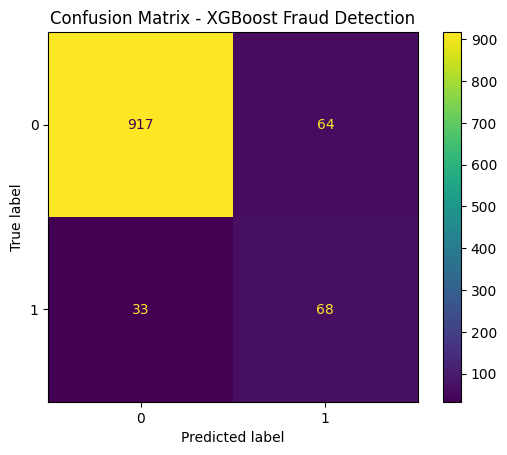

In [11]:
# Confusion Matrix 
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - XGBoost Fraud Detection")
plt.show()

In [12]:
# save model and feature names
os.makedirs("artifacts", exist_ok=True)

joblib.dump(xgb_pipeline, "artifacts/xgboost_fraud_algorithm.joblib")

feature_names = X.columns.tolist()
with open("artifacts/feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=2)

print("Saved:")
print("- artifacts/xgboost_fraud_algorithm.joblib")
print("- artifacts/feature_names.json")

Saved:
- artifacts/xgboost_fraud_algorithm.joblib
- artifacts/feature_names.json


In [13]:
# Load model and create reusable prediction function
model = joblib.load("artifacts/xgboost_fraud_algorithm.joblib")

with open("artifacts/feature_names.json", "r") as f:
    feature_names = json.load(f)

def predict_fraud_from_features(input_data: dict):
    """
    Predict fraud using the trained XGBoost pipeline.
    input_data should contain engineered numeric features.
    """
    input_df = pd.DataFrame([input_data])

    for col in feature_names:
        if col not in input_df.columns:
            input_df[col] = 0

    input_df = input_df[feature_names]

    pred = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0][1]

    return {
        "prediction_label": int(pred),
        "prediction_text": "Fraud" if pred == 1 else "No Fraud",
        "fraud_probability": float(proba)
    }

In [14]:
# manual no fraud engineered test-case
no_fraud_test_case = {
    "phy_same": 0,
    "phy_count": 2,
    "claim_period_days": 3,
    "admission_period_days": 2,
    "age": 45,
    "alife": 1,

    "provider_InscClaimAmtReimbursed_mean": 12000,
    "provider_InscClaimAmtReimbursed_std": 2000,
    "provider_DeductibleAmtPaid_mean": 200,
    "provider_DeductibleAmtPaid_std": 50,

    "bene_InscClaimAmtReimbursed_mean": 10000,
    "bene_InscClaimAmtReimbursed_std": 1500,
    "bene_DeductibleAmtPaid_mean": 180,
    "bene_DeductibleAmtPaid_std": 40,

    "diag1_InscClaimAmtReimbursed_mean": 11000,
    "diag1_InscClaimAmtReimbursed_std": 1800,
    "diag1_DeductibleAmtPaid_mean": 190,
    "diag1_DeductibleAmtPaid_std": 45,

    "provider_NoOfMonths_PartACov_mean": 12,
    "provider_NoOfMonths_PartBCov_mean": 12,
    "bene_NoOfMonths_PartACov_mean": 12,
    "bene_NoOfMonths_PartBCov_mean": 12,
    "diag1_NoOfMonths_PartACov_mean": 12,
    "diag1_NoOfMonths_PartBCov_mean": 12,

    "provider_IPAnnualReimbursementAmt_mean": 5000,
    "provider_OPAnnualReimbursementAmt_mean": 7000,
    "bene_IPAnnualReimbursementAmt_mean": 4500,
    "bene_OPAnnualReimbursementAmt_mean": 6500,
    "diag1_IPAnnualReimbursementAmt_mean": 4800,
    "diag1_OPAnnualReimbursementAmt_mean": 6800
}

In [15]:
# manual fraud engineered test case 
fraud_test_case = {
    "phy_same": 3,
    "phy_count": 3,
    "claim_period_days": 15,
    "admission_period_days": 12,
    "age": 78,
    "alife": 1,

    "provider_InscClaimAmtReimbursed_mean": 95000,
    "provider_InscClaimAmtReimbursed_std": 30000,
    "provider_DeductibleAmtPaid_mean": 2500,
    "provider_DeductibleAmtPaid_std": 900,

    "bene_InscClaimAmtReimbursed_mean": 87000,
    "bene_InscClaimAmtReimbursed_std": 25000,
    "bene_DeductibleAmtPaid_mean": 2200,
    "bene_DeductibleAmtPaid_std": 850,

    "diag1_InscClaimAmtReimbursed_mean": 91000,
    "diag1_InscClaimAmtReimbursed_std": 27000,
    "diag1_DeductibleAmtPaid_mean": 2400,
    "diag1_DeductibleAmtPaid_std": 870,

    "provider_NoOfMonths_PartACov_mean": 12,
    "provider_NoOfMonths_PartBCov_mean": 12,
    "bene_NoOfMonths_PartACov_mean": 12,
    "bene_NoOfMonths_PartBCov_mean": 12,
    "diag1_NoOfMonths_PartACov_mean": 12,
    "diag1_NoOfMonths_PartBCov_mean": 12,

    "provider_IPAnnualReimbursementAmt_mean": 55000,
    "provider_OPAnnualReimbursementAmt_mean": 40000,
    "bene_IPAnnualReimbursementAmt_mean": 50000,
    "bene_OPAnnualReimbursementAmt_mean": 37000,
    "diag1_IPAnnualReimbursementAmt_mean": 53000,
    "diag1_OPAnnualReimbursementAmt_mean": 39000
}

In [16]:
# Run manual engineered test cases 
print("No Fraud Test Case Result:")
print(predict_fraud_from_features(no_fraud_test_case))

print("\nFraud Test Case Result:")
print(predict_fraud_from_features(fraud_test_case))

No Fraud Test Case Result:
{'prediction_label': 0, 'prediction_text': 'No Fraud', 'fraud_probability': 0.001083669252693653}

Fraud Test Case Result:
{'prediction_label': 0, 'prediction_text': 'No Fraud', 'fraud_probability': 0.0012416146928444505}


In [17]:
# Dashboard style Input mapper
def map_dashboard_input_to_model_features(claim: dict):
    """
    Temporary demo mapping from dashboard claim input
    to model-ready engineered features.
    """

    claim_amount = claim.get("claim_amount", 0)
    procedure_count = claim.get("procedure_count", 1)
    age = claim.get("age", 0)
    admission_type = claim.get("admission_type", "planned").lower()
    out_of_pocket = claim.get("out_of_pocket", 0)

    claim_period_days = 2 if admission_type == "planned" else 6
    admission_period_days = 1 if admission_type == "planned" else 5
    phy_count = min(max(procedure_count, 1), 3)
    phy_same = 0 if procedure_count <= 2 else 3

    return {
        "phy_same": phy_same,
        "phy_count": phy_count,
        "claim_period_days": claim_period_days,
        "admission_period_days": admission_period_days,
        "age": age,
        "alife": 1,

        "provider_InscClaimAmtReimbursed_mean": claim_amount * 1.00,
        "provider_InscClaimAmtReimbursed_std": claim_amount * 0.20,
        "provider_DeductibleAmtPaid_mean": out_of_pocket,
        "provider_DeductibleAmtPaid_std": max(out_of_pocket * 0.10, 1),

        "bene_InscClaimAmtReimbursed_mean": claim_amount * 0.95,
        "bene_InscClaimAmtReimbursed_std": claim_amount * 0.18,
        "bene_DeductibleAmtPaid_mean": out_of_pocket * 0.95,
        "bene_DeductibleAmtPaid_std": max(out_of_pocket * 0.08, 1),

        "diag1_InscClaimAmtReimbursed_mean": claim_amount * 0.98,
        "diag1_InscClaimAmtReimbursed_std": claim_amount * 0.19,
        "diag1_DeductibleAmtPaid_mean": out_of_pocket * 0.98,
        "diag1_DeductibleAmtPaid_std": max(out_of_pocket * 0.09, 1),

        "provider_NoOfMonths_PartACov_mean": 12,
        "provider_NoOfMonths_PartBCov_mean": 12,
        "bene_NoOfMonths_PartACov_mean": 12,
        "bene_NoOfMonths_PartBCov_mean": 12,
        "diag1_NoOfMonths_PartACov_mean": 12,
        "diag1_NoOfMonths_PartBCov_mean": 12,

        "provider_IPAnnualReimbursementAmt_mean": claim_amount * 0.45,
        "provider_OPAnnualReimbursementAmt_mean": claim_amount * 0.55,
        "bene_IPAnnualReimbursementAmt_mean": claim_amount * 0.42,
        "bene_OPAnnualReimbursementAmt_mean": claim_amount * 0.52,
        "diag1_IPAnnualReimbursementAmt_mean": claim_amount * 0.44,
        "diag1_OPAnnualReimbursementAmt_mean": claim_amount * 0.54,
    }

def predict_from_dashboard_claim(claim: dict):
    model_features = map_dashboard_input_to_model_features(claim)
    return predict_fraud_from_features(model_features)

In [18]:
# dashboard style low risk claim
dashboard_no_fraud_claim = {
    "full_name": "Aman Verma",
    "age": 42,
    "gender": "Male",
    "hospital_name": "General Health Center",
    "provider_name": "Dr. Singh",
    "location": "Delhi",
    "diagnosis_code": "D100",
    "procedure_code": "P200",
    "procedure_count": 1,
    "admission_type": "planned",
    "date_of_service": "2026-04-10",
    "claim_amount": 12000,
    "insurance_coverage": 10000,
    "out_of_pocket": 2000,
    "billing_date": "2026-04-11",
    "description": "Standard medical treatment"
}

In [19]:
# dashboard high risk claim 
dashboard_fraud_claim = {
    "full_name": "Rakesh Kumar",
    "age": 76,
    "gender": "Male",
    "hospital_name": "Metro Advanced Hospital",
    "provider_name": "Dr. X",
    "location": "Mumbai",
    "diagnosis_code": "D999",
    "procedure_code": "P999",
    "procedure_count": 5,
    "admission_type": "emergency",
    "date_of_service": "2026-04-10",
    "claim_amount": 98000,
    "insurance_coverage": 85000,
    "out_of_pocket": 13000,
    "billing_date": "2026-04-11",
    "description": "Complex emergency billing pattern"
}

In [20]:
# run dashboard style test cases 
print("Dashboard No-Fraud Claim Result:")
print(predict_from_dashboard_claim(dashboard_no_fraud_claim))

print("\nDashboard Fraud Claim Result:")
print(predict_from_dashboard_claim(dashboard_fraud_claim))

Dashboard No-Fraud Claim Result:
{'prediction_label': 0, 'prediction_text': 'No Fraud', 'fraud_probability': 0.0008053577621467412}

Dashboard Fraud Claim Result:
{'prediction_label': 0, 'prediction_text': 'No Fraud', 'fraud_probability': 0.0006588660180568695}
